In [ ]:
# ------------------------------------------
# 1. Import Libraries
# ------------------------------------------

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

print("Environment Ready.")

Environment Ready.


In [17]:
# ------------------------------------------
# 2. Load Test Data
# ------------------------------------------

X_test = pd.read_csv("../outputs/X_test.csv")
y_test = pd.read_csv("../outputs/y_test.csv")["shortage"]

print("Test set shape:", X_test.shape)
print("Shortage rate in test set:", round(y_test.mean(), 3))

Test set shape: (123, 6)
Shortage rate in test set: 0.301


In [18]:
# ------------------------------------------
# 3. Load Trained Models
# ------------------------------------------

log_reg = joblib.load("../models/logistic_regression.joblib")
rf_model = joblib.load("../models/random_forest.joblib")
svm_model = joblib.load("../models/svm_rbf.joblib")
xgb_model = joblib.load("../models/xgboost.joblib")

models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf_model,
    "SVM (RBF)": svm_model,
    "XGBoost": xgb_model
}

print("All models loaded successfully.")

All models loaded successfully.


In [19]:
# ------------------------------------------
# 4. Generate Predictions and Compute Metrics
# ------------------------------------------

results = []
predictions = {}
probabilities = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    predictions[name] = y_pred
    probabilities[name] = y_proba

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).sort_values("F1-Score", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Random Forest,0.902439,0.790698,0.918919,0.850000,0.966059
3,XGBoost,0.869919,0.733333,0.891892,0.804878,0.963545
2,SVM (RBF),0.829268,0.653846,0.918919,0.764045,0.929604
0,Logistic Regression,0.837398,0.680851,0.864865,0.761905,0.868636


In [20]:
# ------------------------------------------
# 5. Detailed Classification Reports
# ------------------------------------------

for name, y_pred in predictions.items():
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=["No Shortage", "Shortage"]))


=== Logistic Regression ===
              precision    recall  f1-score   support

 No Shortage       0.93      0.83      0.88        86
    Shortage       0.68      0.86      0.76        37

    accuracy                           0.84       123
   macro avg       0.81      0.85      0.82       123
weighted avg       0.86      0.84      0.84       123


=== Random Forest ===
              precision    recall  f1-score   support

 No Shortage       0.96      0.90      0.93        86
    Shortage       0.79      0.92      0.85        37

    accuracy                           0.90       123
   macro avg       0.88      0.91      0.89       123
weighted avg       0.91      0.90      0.90       123


=== SVM (RBF) ===
              precision    recall  f1-score   support

 No Shortage       0.96      0.79      0.87        86
    Shortage       0.65      0.92      0.76        37

    accuracy                           0.83       123
   macro avg       0.81      0.85      0.82       123
wei

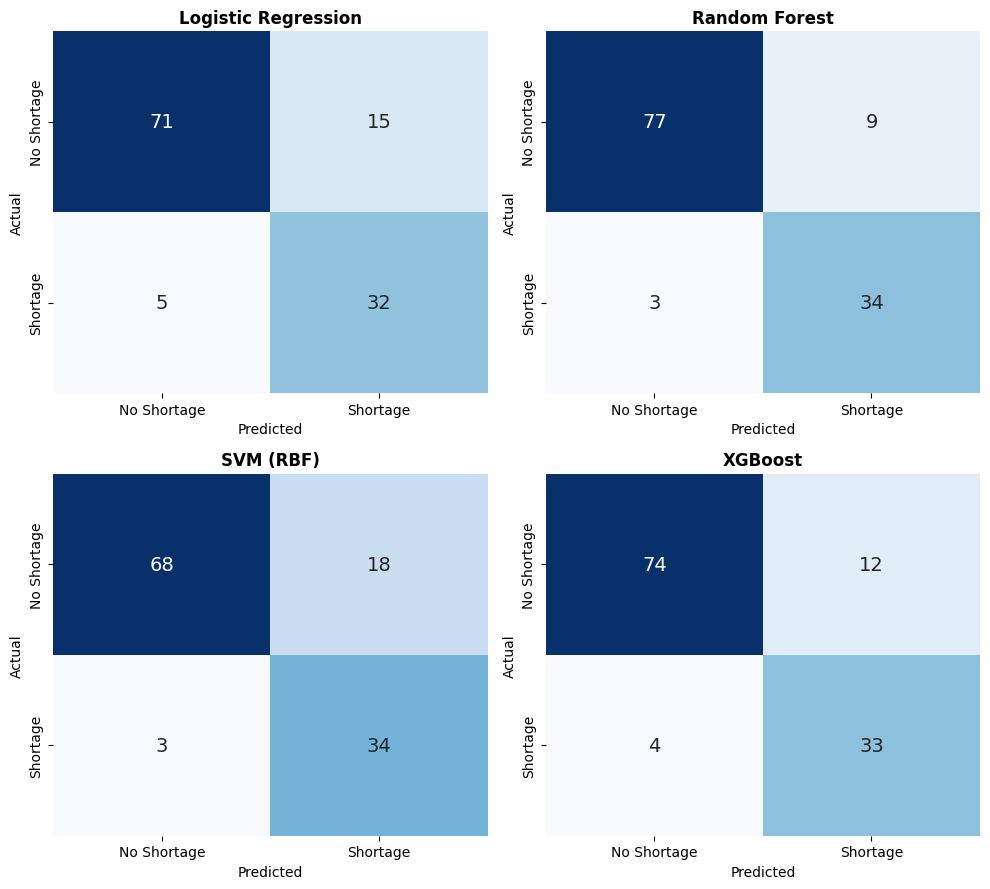

In [21]:
# ------------------------------------------
# 6. Confusion Matrices (All Models)
# ------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(10, 9))

for ax, (name, y_pred) in zip(axes.flat, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=["No Shortage", "Shortage"],
        yticklabels=["No Shortage", "Shortage"],
        cbar=False, annot_kws={"size": 14}
    )
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.tight_layout()
plt.savefig("../outputs/confusion_matrices.png", bbox_inches="tight")
plt.show()

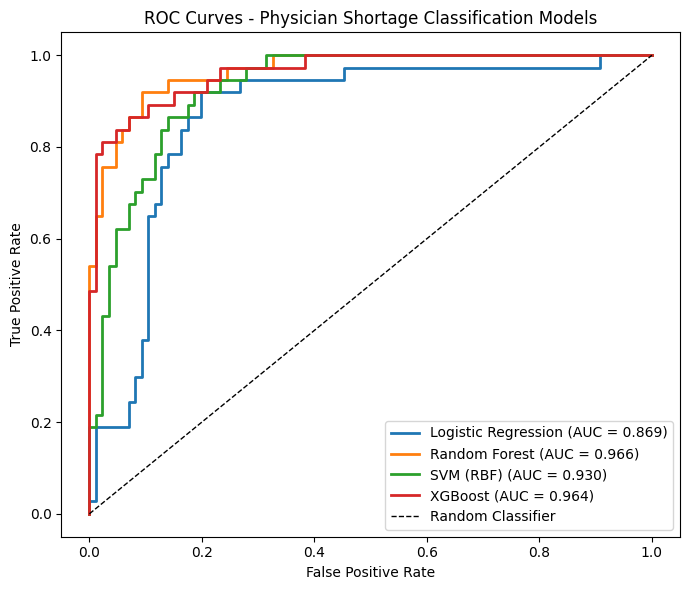

In [22]:
# ------------------------------------------
# 7. ROC Curves (All Models)
# ------------------------------------------

plt.figure(figsize=(7, 6))

for name, y_proba in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Physician Shortage Classification Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../outputs/roc_curves.png", bbox_inches="tight")
plt.show()

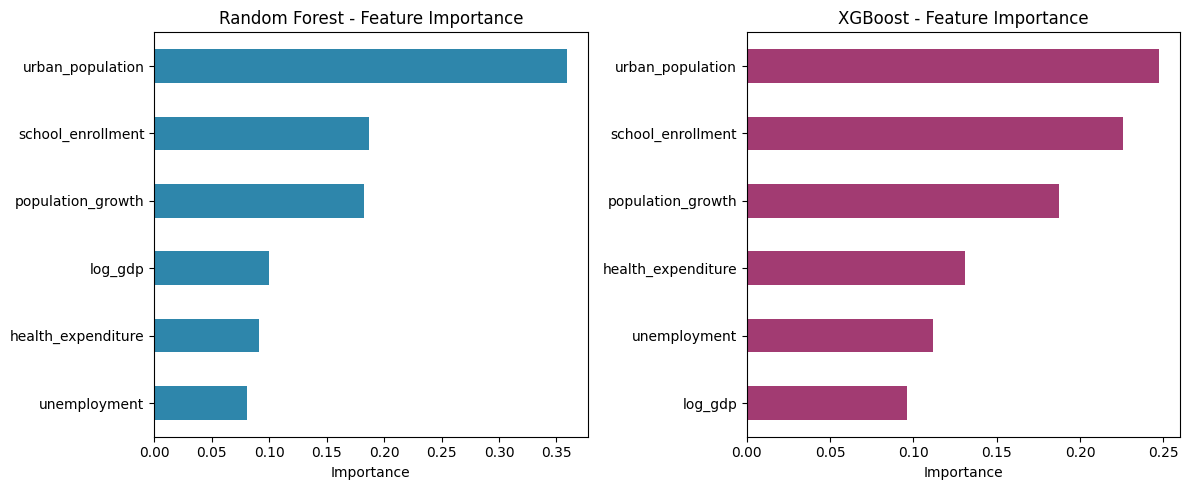

In [23]:
# ------------------------------------------
# 8. Feature Importance (Random Forest & XGBoost)
# ------------------------------------------

FEATURES = X_test.columns.tolist()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

rf_importance = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values()
rf_importance.plot(kind="barh", ax=axes[0], color="#2E86AB")
axes[0].set_title("Random Forest - Feature Importance")
axes[0].set_xlabel("Importance")

xgb_importance = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values()
xgb_importance.plot(kind="barh", ax=axes[1], color="#A23B72")
axes[1].set_title("XGBoost - Feature Importance")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.savefig("../outputs/feature_importance.png", bbox_inches="tight")
plt.show()

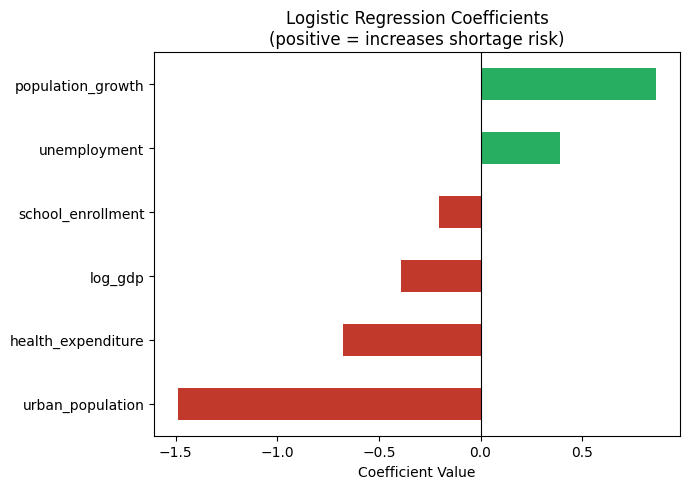

In [24]:
# ------------------------------------------
# 9. Logistic Regression Coefficients
# ------------------------------------------

lr_coefs = pd.Series(log_reg.coef_[0], index=FEATURES).sort_values()

plt.figure(figsize=(7, 5))
colors = ["#C0392B" if v < 0 else "#27AE60" for v in lr_coefs.values]
lr_coefs.plot(kind="barh", color=colors)
plt.title("Logistic Regression Coefficients\n(positive = increases shortage risk)")
plt.xlabel("Coefficient Value")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("../outputs/logistic_coefficients.png", bbox_inches="tight")
plt.show()

In [25]:
# ------------------------------------------
# 10. Save Model Comparison Table
# ------------------------------------------

results_df.to_csv("../outputs/model_comparison.csv", index=False)

rf_importance.sort_values(ascending=False).to_csv("../outputs/rf_feature_importance.csv")
xgb_importance.sort_values(ascending=False).to_csv("../outputs/xgb_feature_importance.csv")
lr_coefs.to_csv("../outputs/lr_coefficients.csv")

print("All evaluation outputs saved to outputs/")

All evaluation outputs saved to outputs/


In [26]:
# ------------------------------------------
# 0. Define Random State (must match 04_model_building.ipynb)
# ------------------------------------------

RANDOM_STATE = 42

In [27]:
# ------------------------------------------
# 11. Attach Country Identifiers to Test Predictions
# ------------------------------------------

df_full = pd.read_csv("../data/final_dataset_model_ready.csv")

# Recreate the exact same split as 04_model_building.ipynb,
# but keep the identifier columns this time
from sklearn.model_selection import train_test_split

identifiers = df_full[["Country Name", "Country Code", "Year"]]

_, id_test = train_test_split(
    identifiers,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_full["shortage"]
)

id_test = id_test.reset_index(drop=True)

print("Identifier test set shape:", id_test.shape)
id_test.head()

Identifier test set shape: (123, 3)


,Country Name,Country Code,Year
0,Georgia,GEO,2020
1,Viet Nam,VNM,2020
2,Costa Rica,CRI,2018
3,Zimbabwe,ZWE,2019
4,Andorra,AND,2021


In [28]:
# ------------------------------------------
# 12. Combine Identifiers with Actual and Predicted Labels
# ------------------------------------------

results_table = id_test.copy()
results_table["Actual"] = y_test.values
results_table["Predicted (Random Forest)"] = predictions["Random Forest"]
results_table["Correct"] = results_table["Actual"] == results_table["Predicted (Random Forest)"]

results_table.head(10)

,Country Name,Country Code,Year,Actual,Predicted (Random Forest),Correct
0,Georgia,GEO,2020,0,0,True
1,Viet Nam,VNM,2020,0,1,False
2,Costa Rica,CRI,2018,0,0,True
3,Zimbabwe,ZWE,2019,1,1,True
4,Andorra,AND,2021,0,0,True
5,Gabon,GAB,2020,1,1,True
6,Senegal,SEN,2022,1,1,True
7,Mozambique,MOZ,2020,1,1,True
8,Vanuatu,VUT,2019,1,1,True
9,Spain,ESP,2021,0,0,True


In [29]:
# ------------------------------------------
# 13. All Misclassified Countries (Random Forest)
# ------------------------------------------

errors = results_table[results_table["Correct"] == False].copy()
errors["Error Type"] = errors.apply(
    lambda row: "False Negative (missed shortage)" if row["Actual"] == 1 and row["Predicted (Random Forest)"] == 0
    else "False Positive (false alarm)",
    axis=1
)

errors = errors.sort_values("Error Type")
errors

,Country Name,Country Code,Year,Actual,Predicted (Random Forest),Correct,Error Type
11,Bahrain,BHR,2020,1,0,False,False Negative (missed shortage)
69,Thailand,THA,2021,1,0,False,False Negative (missed shortage)
88,Nepal,NPL,2021,1,0,False,False Negative (missed shortage)
1,Viet Nam,VNM,2020,0,1,False,False Positive (false alarm)
31,Sri Lanka,LKA,2018,0,1,False,False Positive (false alarm)
43,Tajikistan,TJK,2018,0,1,False,False Positive (false alarm)
44,South Africa,ZAF,2022,0,1,False,False Positive (false alarm)
45,Kazakhstan,KAZ,2018,0,1,False,False Positive (false alarm)
54,Maldives,MDV,2019,0,1,False,False Positive (false alarm)
68,Gabon,GAB,2018,0,1,False,False Positive (false alarm)


In [30]:
# ------------------------------------------
# 14. Save Misclassification Table
# ------------------------------------------

errors.to_csv("../outputs/misclassified_countries.csv", index=False)
results_table.to_csv("../outputs/full_test_predictions.csv", index=False)

print("Saved.")

Saved.
